<a href="https://colab.research.google.com/github/mnasir-oj/Concrete-Compressive-Strength-Prediction-using-a-Multi-Layer-Perceptron-MLP-/blob/main/Concrete_Compressive_Strength_Prediction_using_a_(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Concrete Compressive Strength Prediction using a Multi-Layer Perceptron (MLP)

This notebook demonstrates how to build and train a simple Multi-Layer Perceptron (MLP) neural network using PyTorch to predict the compressive strength of concrete based on various input features.

## Dataset
The dataset used, `Concrete_Data.csv`, contains several features related to concrete components (cement, slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate) and age, with 'Concrete compressive strength' as the target variable.

## Analysis Steps:
1.  **Model Definition**: A MLP models are defined:
2.  **Data Loading and Inspection**: The dataset is loaded, and a preliminary check for missing values and descriptive statistics is performed.
3.  **Exploratory Data Analysis (EDA)**: A correlation matrix is visualized to understand relationships between features.
4.  **Data Preprocessing**: Features are separated from the target, and input features are standardized using `StandardScaler`.
5.  **PyTorch Data Preparation**: Data is converted into PyTorch tensors and split into training and testing sets.
6.  **Model Setup**: The `ConcreteMLP` model, Mean Squared Error (MSE) loss function, and Adam optimizer are initialized.
7.  **Model Training**: The model is trained over several epochs, with the training loss being recorded.
8.  **Training Loss Visualization**: The training loss over epochs is plotted to observe convergence.
9.  **Model Evaluation**: The trained model's performance is evaluated on both training and testing datasets using MSE and Root Mean Squared Error (RMSE).

In [111]:
import torch
from torch import nn
import torch.optim as optim

input_size = 8
hidden_size = 16
output_size = 1

simple_mlp = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, output_size
))
print(simple_mlp)



Sequential(
  (0): Linear(in_features=8, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


### ConcreteMLP Class Definition
This cell defines a more structured MLP model as a Python class inheriting from `nn.Module`. This approach allows for more complex architectures and custom forward passes. It includes two linear layers and a ReLU activation function.

In [112]:
class ConcreteMLP(nn.Module):
  def __init__(self, input_size=8, hidden_size=16, output_size=1):
    super(ConcreteMLP,self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, output_size)

  def forward(self,x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

model = ConcreteMLP()
print(model)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


### Data Loading and Initial Inspection
This section loads the 'Concrete_Data.csv' dataset into a pandas DataFrame and displays the first few rows to get an initial understanding of the data structure and content.

In [113]:
import pandas as pd

from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('/content/drive/MyDrive/fd 2/Concrete_Data.csv')
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [114]:
# check for missing data
data.isna().sum()

,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
"Concrete compressive strength(MPa, megapascals)",0


### Descriptive Statistics
To better understand the spread and characteristics of our data, let's look at some descriptive statistics for each column.

In [115]:
data.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### Correlation Matrix Visualization
Next, we'll visualize the correlations between our features and the target variable using a heatmap. This can reveal important relationships and potential collinearity.

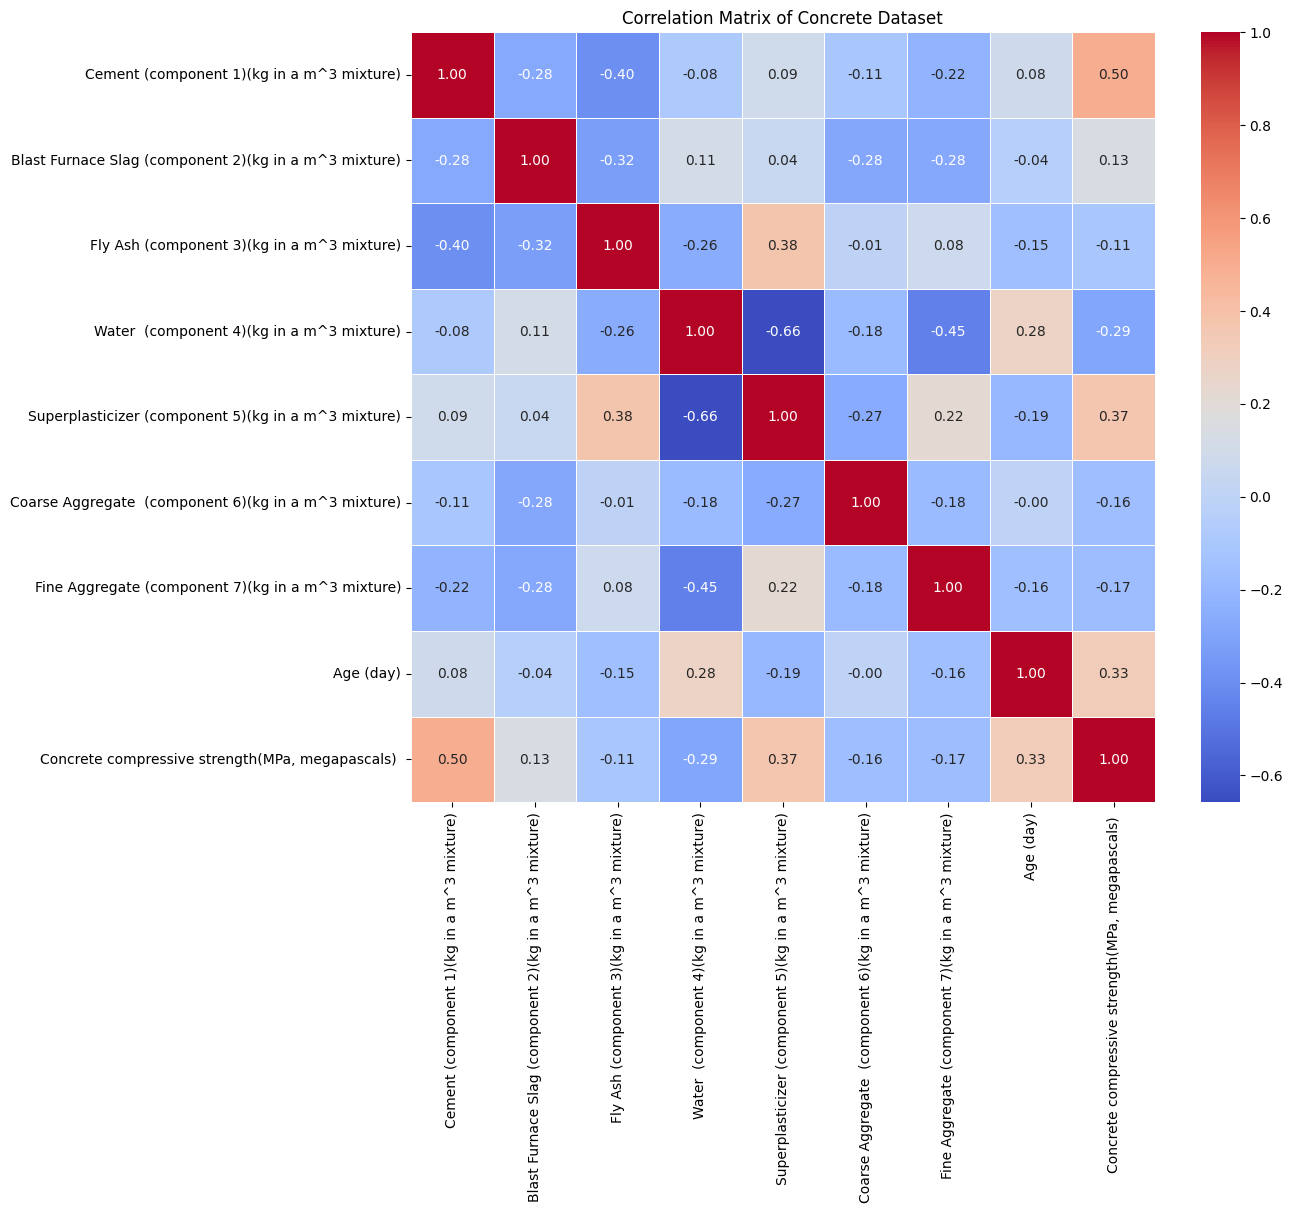

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Concrete Dataset')
plt.show()

### Feature and Target Separation
Now, let's separate our dataset into features (X) which our model will learn from, and the target variable (y), which is what we're trying to predict (the concrete compressive strength).

In [117]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1].values.reshape(-1,1)

### Feature Scaling (Standardization)
The input features (X) are standardized using `StandardScaler`. Standardization transforms the data to have a mean of 0 and a standard deviation of 1

In [118]:
# Standardixed inputs
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [119]:
# Convert to pytorch tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Shuffle and split
torch.manual_seed(42)
num_samples = X_tensor.shape[0]
indices = torch.randperm(num_samples)

# split into training an d testing data set
train_size = int(0.8 * num_samples)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X_tensor[train_indices]
y_train = y_tensor[train_indices]

X_test = X_tensor[test_indices]
y_test = y_tensor[test_indices]

# Print shapes
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 824
Testing samples: 206


### Model, Loss Function, and Optimizer Setup
Here, we'll set up the core components for training: our `ConcreteMLP` model, the Mean Squared Error (MSE) as our chosen loss function, and the Adam optimizer to adjust our model's weights during training.

In [120]:
# Instantiate the model
model = ConcreteMLP()
# Define loss function
loss_fn = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr= 0.01)


print(model)
print(optimizer)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [121]:
epochs = 300

train_loss = []

for epoch in range(epochs):

  y_pred = model(X_train)

  loss = loss_fn(y_pred, y_train)

  # Zero gradients before backpropagation
  optimizer.zero_grad()

  # Perform backpropagation
  loss.backward()

  # Update model parameters
  optimizer.step()

  train_loss.append(loss.item())

  if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/300], Loss: 846.4659
Epoch [100/300], Loss: 219.5669
Epoch [150/300], Loss: 163.2395
Epoch [200/300], Loss: 140.0677
Epoch [250/300], Loss: 130.9562
Epoch [300/300], Loss: 123.8815


### Training Loss Visualization
After training, let's visualize how our training loss decreased over the epochs. This plot helps us understand if the model learned effectively and if it converged.

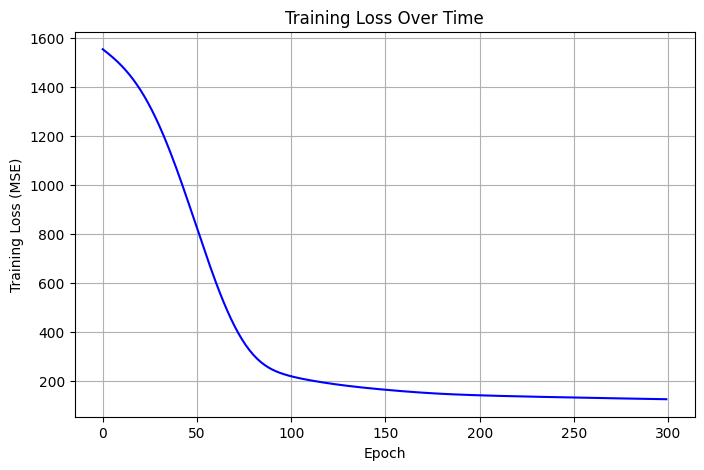

In [122]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_loss, linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

### Model Evaluation
After training, this cell evaluates the model's performance on both the training and testing datasets. It uses the trained model to make predictions and calculates the final Mean Squared Error (MSE) loss for both sets, indicating how well the model generalizes.

In [123]:
# Evaluate model performance

with torch.no_grad():
    # Predict on train set
    train_preds = model(X_train)
    train_loss = loss_fn(train_preds, y_train)

    # Predict on test set
    test_preds = model(X_test)
    test_loss = loss_fn(test_preds, y_test)

print(f"Final Training Loss (MSE): {train_loss.item():.4f}")
print(f"Final Testing Loss (MSE): {test_loss.item():.4f}")

Final Training Loss (MSE): 123.7480
Final Testing Loss (MSE): 136.0419


In [124]:
# Calculate RMSE
train_rmse = torch.sqrt(train_loss)
test_rmse = torch.sqrt(test_loss)

print(f"Training RMSE: {train_rmse.item():.2f} MPa")
print(f"Testing RMSE: {test_rmse.item():.2f} MPa")

Training RMSE: 11.12 MPa
Testing RMSE: 11.66 MPa
